In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
df=pd.read_csv('aug_train.csv')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), object(10)
me

In [6]:
df.shape

(19158, 14)

In [8]:
(df.isnull().sum()/len(df))*100

,0
enrollee_id,0.000000
city,0.000000
city_development_index,0.000000
gender,23.530640
relevent_experience,0.000000
enrolled_university,2.014824
education_level,2.401086
major_discipline,14.683161
experience,0.339284
company_size,30.994885


In [9]:
df['gender']=df['gender'].fillna('Unknown')
df['city']=df['city'].fillna('Unknown')
df['company_size']=df['company_size'].fillna('Unknown')
df['company_type']=df['company_type'].fillna('Unknown')
df['education_level']=df['education_level'].fillna('Unknown')
df['major_discipline']=df['major_discipline'].fillna('Unknown')
df['experience']=df['experience'].fillna(0)
df['last_new_job']=df['last_new_job'].fillna(0)
df['enrolled_university']=df['enrolled_university'].fillna('Unknown')

In [10]:
df.isnull().sum()

,0
enrollee_id,0
city,0
city_development_index,0
gender,0
relevent_experience,0
enrolled_university,0
education_level,0
major_discipline,0
experience,0
company_size,0


In [12]:
df['Job_Status'] = df['target'].map({
    0: 'Stay',
    1: 'Leave'
})

In [13]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target,Job_Status
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,Unknown,Unknown,1,36,1.0,Leave
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0,Stay
2,11561,city_21,0.624,Unknown,No relevent experience,Full time course,Graduate,STEM,5,Unknown,Unknown,never,83,0.0,Stay
3,33241,city_115,0.789,Unknown,No relevent experience,Unknown,Graduate,Business Degree,<1,Unknown,Pvt Ltd,never,52,1.0,Leave
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0,Stay


In [14]:
df['company_type'].unique()

array(['Unknown', 'Pvt Ltd', 'Funded Startup', 'Early Stage Startup',
       'Other', 'Public Sector', 'NGO'], dtype=object)

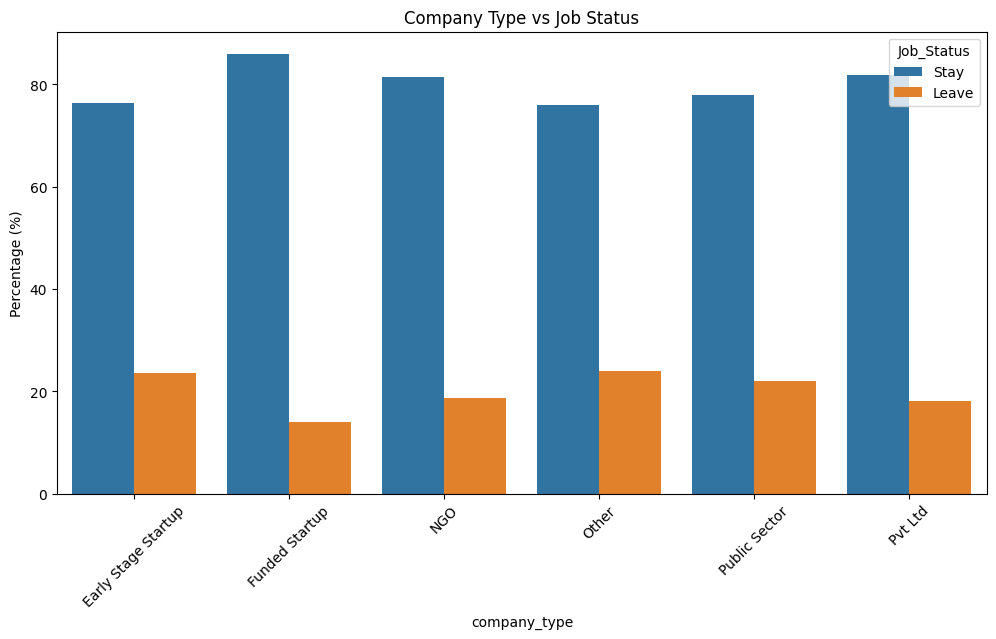

In [17]:
df_company = df[df['company_type'] != 'Unknown']
company_target = (
    df_company.groupby('company_type')['Job_Status']
    .value_counts(normalize=True)
    .mul(100)
    .rename('Percentage')
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=company_target,
    x='company_type',
    y='Percentage',
    hue='Job_Status'
)

plt.xticks(rotation=45)
plt.ylabel("Percentage (%)")
plt.title("Company Type vs Job Status")

plt.show()

In [ ]:
# "Early Stage Startups have the highest proportion of employees likely to leave.
# A separate analysis shows they also tend to have less experienced employees, suggesting workforce experience may be one factor influencing job changes.
# Additional analyses are needed to confirm this relationship."

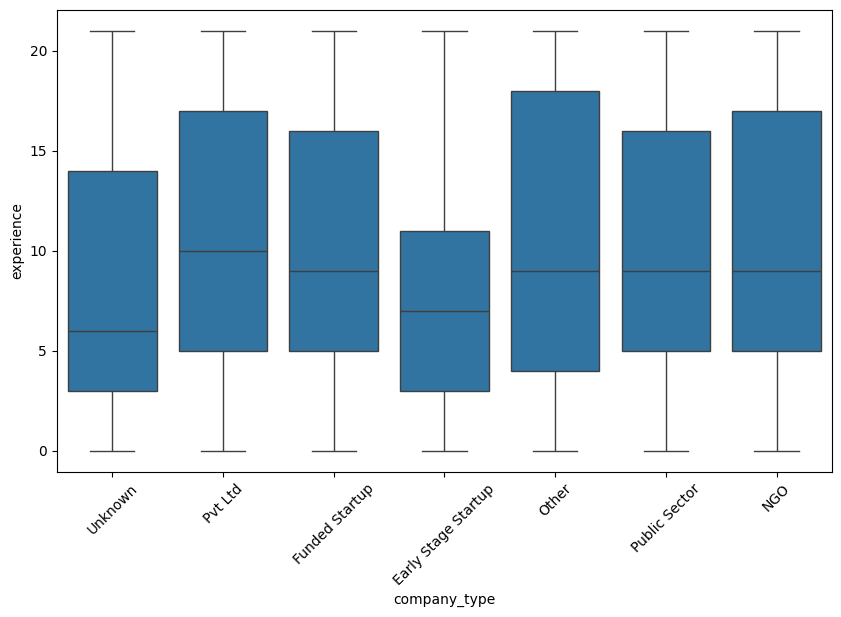

In [22]:
df['experience'] = df['experience'].replace({'<1':0, '>20':21}).astype(int)

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='company_type',
    y='experience'
)

plt.xticks(rotation=45)
plt.show()

In [19]:
df['experience'].unique()

array(['>20', '15', '5', '<1', '11', '13', '7', '17', '2', '16', '1', '4',
       '10', '14', '18', '19', '12', '3', '6', '9', '8', '20', 0],
      dtype=object)

<Axes: xlabel='education_level', ylabel='count'>

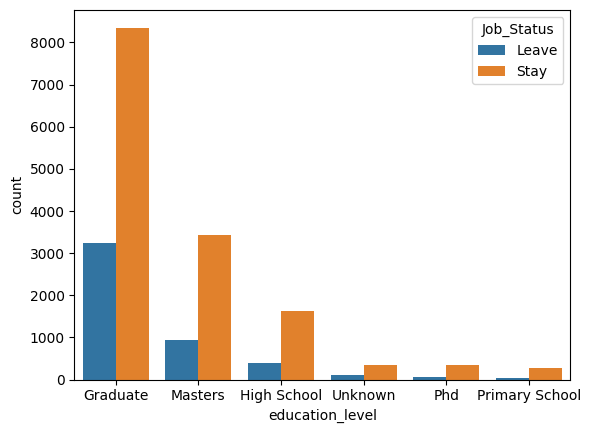

In [26]:
sns.countplot(
    data=df,
    x='education_level',
    hue='Job_Status'
)

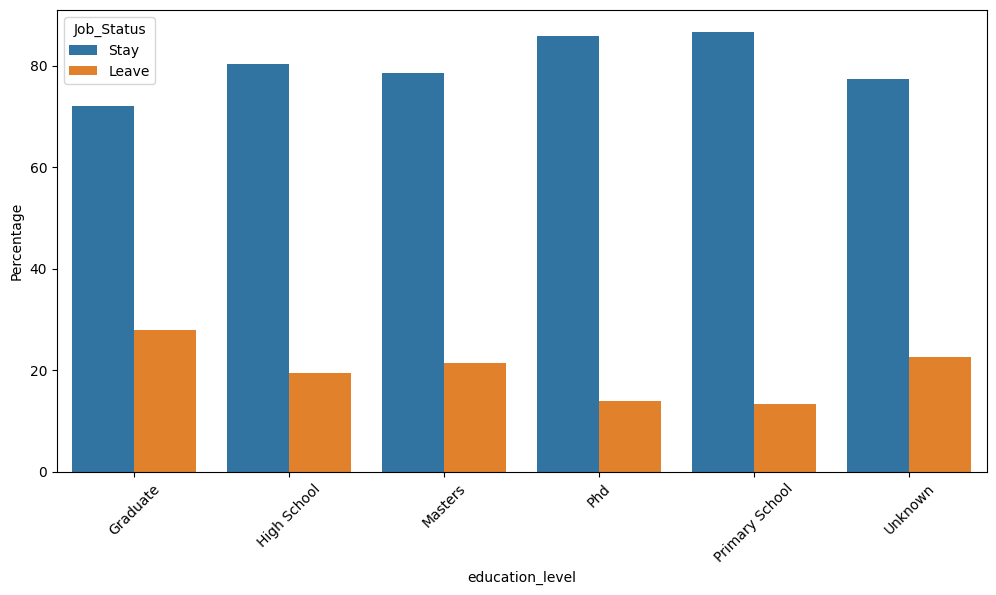

In [28]:
education_target=df.groupby('education_level')['Job_Status'].value_counts(normalize=True).mul(100).rename('Percentage').reset_index()
plt.figure(figsize=(12,6))

sns.barplot(
    data=education_target,
    x='education_level',
    y='Percentage',
    hue='Job_Status'
)
plt.xticks(rotation=45)
plt.show()

<Axes: xlabel='education_level', ylabel='experience'>

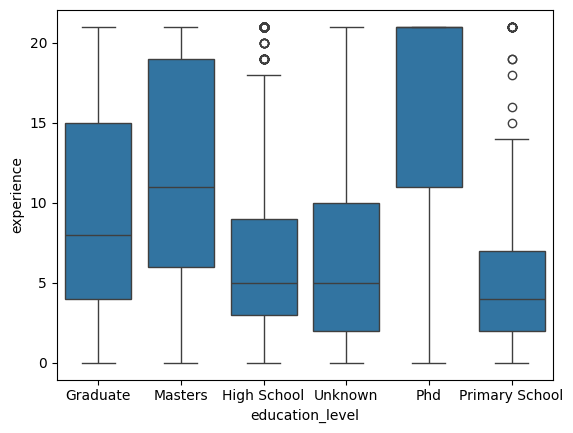

In [29]:
sns.boxplot(
    data=df,
    x='education_level',
    y='experience'
)

In [ ]:
# Candidates with Graduate degrees exhibit the highest likelihood of changing jobs.
# Compared with Master's and PhD holders, they also tend to have fewer years of work experience,
# indicating that early-career professionals may be more inclined to explore new career opportunities.

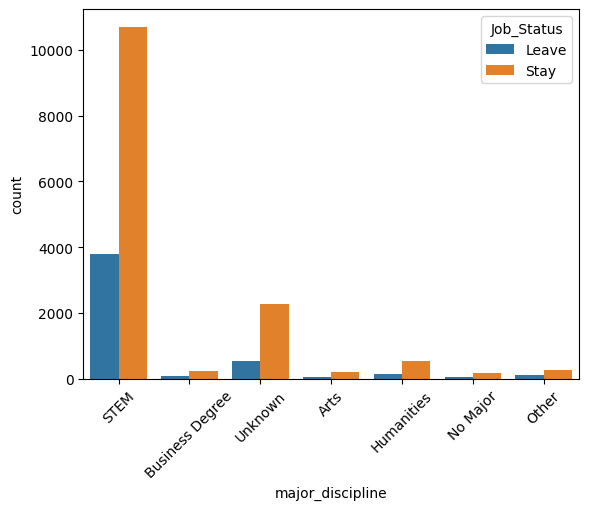

In [33]:
sns.countplot(
    data=df,
    x='major_discipline',
    hue='Job_Status'
)
plt.xticks(rotation=45)
plt.show()

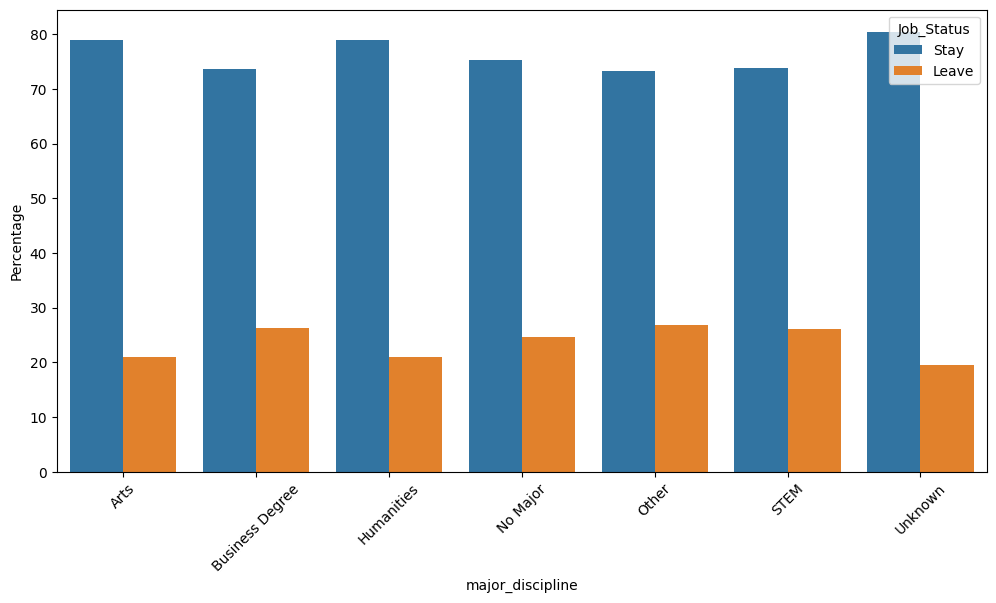

In [35]:
discipline_target=df.groupby('major_discipline')['Job_Status'].value_counts(normalize=True).mul(100).rename('Percentage').reset_index()
plt.figure(figsize=(12,6))

sns.barplot(
    data=discipline_target,
    x='major_discipline',
    y='Percentage',
    hue='Job_Status'
)
plt.xticks(rotation=45)
plt.show()

<Axes: xlabel='major_discipline', ylabel='experience'>

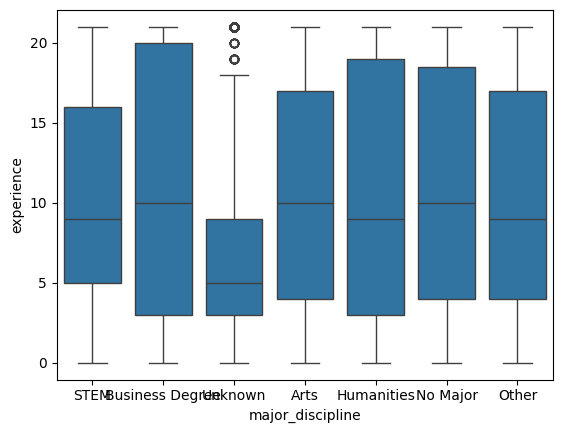

In [36]:
sns.boxplot(
    data=df,
    x='major_discipline',
    y='experience'
)

In [42]:

# The combination of a relatively higher leave rate and moderate work experience suggests that STEM professionals may be more likely to
# explore new career opportunities after completing training.

In [43]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target,Job_Status
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,21,Unknown,Unknown,1,36,1.0,Leave
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0,Stay
2,11561,city_21,0.624,Unknown,No relevent experience,Full time course,Graduate,STEM,5,Unknown,Unknown,never,83,0.0,Stay
3,33241,city_115,0.789,Unknown,No relevent experience,Unknown,Graduate,Business Degree,0,Unknown,Pvt Ltd,never,52,1.0,Leave
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,21,50-99,Funded Startup,4,8,0.0,Stay


In [56]:
Exp_Job=df.groupby('relevent_experience')['Job_Status'].value_counts(normalize=True).mul(100).rename('Percentage').reset_index()
plt.figure(figsize=(12,6))

sns.barplot(
    data=Exp_Job,
    x='relevent_experience',
    y='Percentage',
    hue='Job_Status'
)
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Candidates without relevant work experience are significantly more likely
# to change jobs after completing
# the training program than candidates who already possess relevant experience.

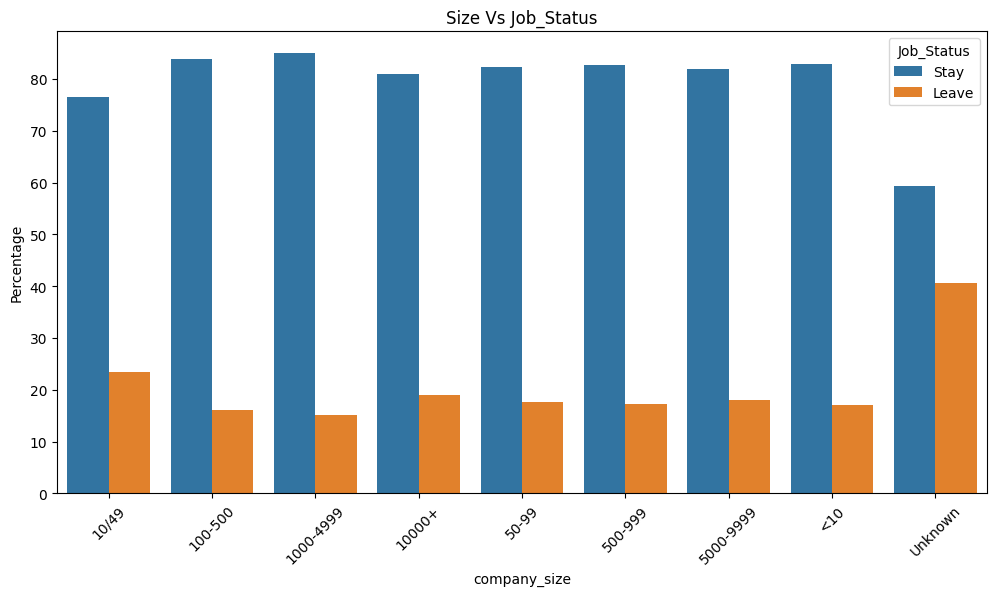

In [53]:
Size_satus=df.groupby('company_size')['Job_Status'].value_counts(normalize=True).mul(100).rename('Percentage').reset_index()
plt.figure(figsize=(12,6))

sns.barplot(
    data=Size_satus,
    x='company_size',
    y='Percentage',
    hue='Job_Status'
)
plt.title('Size Vs Job_Status')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Candidates working in small organizations (10–49 employees) exhibit a higher likelihood
# of changing jobs compared with candidates from medium and large organizations.
# In contrast, employees from companies with 1000–4999 employees show the highest retention rate.

In [57]:
df['CDI_Group'] = pd.cut(
    df['city_development_index'],
    bins=[0.4, 0.6, 0.7, 0.8, 0.9, 1.0],
    labels=[
        'Very Low',
        'Low',
        'Medium',
        'High',
        'Very High'
    ]
)

/tmp/ipykernel_1762/1990134706.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('CDI_Group')['Job_Status']


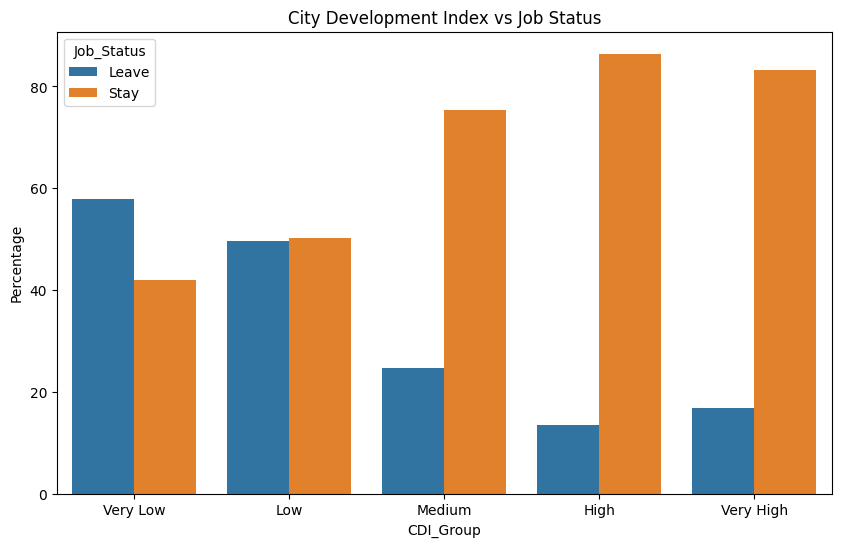

In [58]:
city_target = (
    df.groupby('CDI_Group')['Job_Status']
      .value_counts(normalize=True)
      .mul(100)
      .rename('Percentage')
      .reset_index()
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=city_target,
    x='CDI_Group',
    y='Percentage',
    hue='Job_Status'
)

plt.title("City Development Index vs Job Status")
plt.show()

In [ ]:
# Candidates from less-developed cities appear more likely to seek new job opportunities after training,
# whereas candidates from highly developed cities show higher retention rates.

In [63]:
df['Training_Group'] = pd.cut(
    df['training_hours'],
    bins=[0, 50, 100, 150, 200, 250, 350],
    labels=[
        '0-50',
        '51-100',
        '101-150',
        '151-200',
        '201-250',
        '251-350'
    ]
)

/tmp/ipykernel_1762/507990968.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Training_Group')['Job_Status']


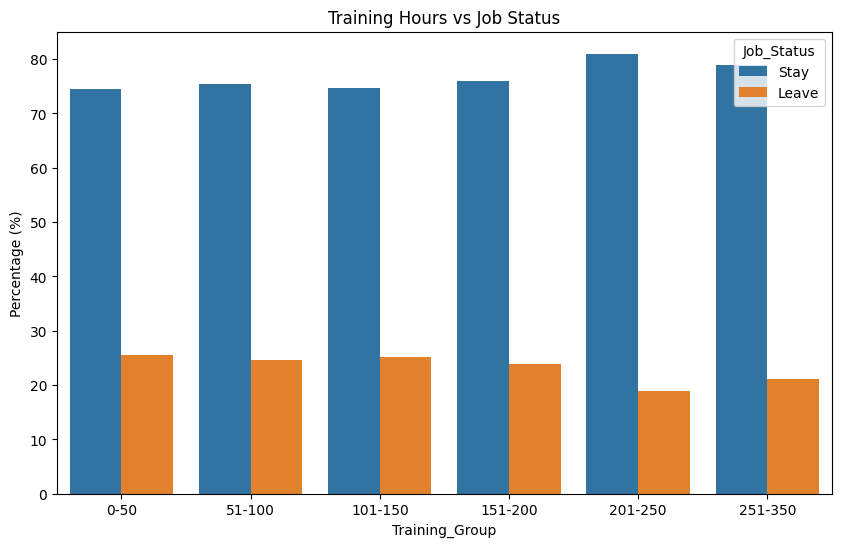

In [64]:
training_target = (
    df.groupby('Training_Group')['Job_Status']
      .value_counts(normalize=True)
      .mul(100)
      .rename('Percentage')
      .reset_index()
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=training_target,
    x='Training_Group',
    y='Percentage',
    hue='Job_Status'
)

plt.title("Training Hours vs Job Status")
plt.ylabel("Percentage (%)")

plt.show()